# ISS Telemetry Analysis

This notebook helps you inspect one saved ISS telemetry `.jsonl` file from a local experiment run.

What this notebook does:
- loads one raw telemetry file
- parses it into a pandas DataFrame
- computes per-item summary statistics
- plots one time-series chart per item
- plots one histogram per item

The goal is to make it easy to decide which channels look useful for anomaly detection and frontend charts.

## Notebook Structure

1. Choose a raw telemetry file
2. Load the JSON lines into a DataFrame
3. Clean timestamps and numeric values
4. Build a simple per-item summary table
5. Plot time-series charts
6. Plot histograms

Everything stays in one notebook and uses straightforward pandas and matplotlib code.

In [1]:
# Import the few libraries we need.
from pathlib import Path
import json
import math

import pandas as pd
import matplotlib.pyplot as plt

# Make plots a bit larger and easier to read.
plt.style.use('default')
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['axes.grid'] = True

## 1. Choose A Telemetry File

By default, this cell picks the newest `.jsonl` file in `data/raw/`.

If you want a different file, replace `selected_file` with a specific path.

In [2]:
# Find raw telemetry files and pick the newest one.
raw_dir = Path('data/raw')
raw_files = sorted(raw_dir.glob('telemetry_*.jsonl'))

if not raw_files:
    raise FileNotFoundError('No telemetry .jsonl files found in data/raw/')

selected_file = raw_files[-1]
selected_file

PosixPath('data/raw/telemetry_2026-04-06_16-02-35.jsonl')

## 2. Load The JSONL File

Each line in the raw file is one telemetry event.

We load every line, turn it into a Python dictionary, and then build a DataFrame.

In [3]:
# Read the file line by line and parse JSON.
records = []

with selected_file.open('r', encoding='utf-8') as infile:
    for line in infile:
        line = line.strip()
        if line:
            records.append(json.loads(line))

df = pd.DataFrame(records)
print(f'Loaded {len(df)} raw telemetry events from {selected_file}')
df.head()

Loaded 8155 raw telemetry events from data/raw/telemetry_2026-04-06_16-02-35.jsonl


,received_at_utc,item,value,timestamp
0,2026-04-06T22:02:36.106067+00:00,USLAB000058,754.9166259765625,2325.620139722228
1,2026-04-06T22:02:36.107320+00:00,USLAB000059,23.386196136474609375,2325.9672783333062
2,2026-04-06T22:02:36.107994+00:00,USLAB000055,2.43251189011812218865316026494838297367095947...,1994.8008344444302
3,2026-04-06T22:02:36.108806+00:00,NODE3000012,17.106964111328125,2326.0421113888424
4,2026-04-06T22:02:36.109437+00:00,NODE3000013,4.437499523162841796875,2326.039028611117


## 3. Clean Timestamps And Numeric Values

The raw data stores values as strings. For analysis, it helps to create:
- a parsed timestamp column
- a numeric version of the value when possible

If a value is not numeric, we keep it and simply leave the numeric column empty for that row.

In [4]:
# Parse the receive timestamp and create a numeric value column.
df['received_at_utc'] = pd.to_datetime(df['received_at_utc'], utc=True)
df['value_numeric'] = pd.to_numeric(df['value'], errors='coerce')

# Sort by item and time so repeated-value and timing calculations are correct.
df = df.sort_values(['item', 'received_at_utc']).reset_index(drop=True)

# A quick look at the cleaned columns.
df[['received_at_utc', 'item', 'value', 'value_numeric']].head()

,received_at_utc,item,value,value_numeric
0,2026-04-06 22:02:36.111819+00:00,NODE3000005,27,27.0
1,2026-04-06 22:12:14.354830+00:00,NODE3000005,27,27.0
2,2026-04-06 22:21:51.445079+00:00,NODE3000005,28,28.0
3,2026-04-06 22:21:57.298323+00:00,NODE3000005,29,29.0
4,2026-04-06 22:22:02.350109+00:00,NODE3000005,30,30.0


## 4. Build A Per-Item Summary Table

This summary is useful for deciding which telemetry channels are interesting.

Useful signs for anomaly detection or charts often include:
- many messages over the run
- numeric values
- more than one unique value
- visible spread in `min`, `max`, and `std`
- a repeated-value percentage that is not too close to 100%

In [5]:
# Compute runtime from the first to the last received event.
runtime_seconds = (
    df['received_at_utc'].max() - df['received_at_utc'].min()
).total_seconds()

if runtime_seconds <= 0:
    runtime_seconds = 1.0

summary_rows = []

for item, item_df in df.groupby('item'):
    item_df = item_df.sort_values('received_at_utc').copy()

    # Compare each value to the previous value for the same item.
    item_df['previous_value'] = item_df['value'].shift(1)
    repeated_mask = item_df['value'] == item_df['previous_value']
    repeated_count = int(repeated_mask.sum())

    # Count unique raw values and calculate numeric statistics when possible.
    numeric_series = item_df['value_numeric'].dropna()
    message_count = len(item_df)

    summary_rows.append({
        'item': item,
        'message_count': message_count,
        'observed_updates_per_sec': message_count / runtime_seconds,
        'repeated_value_percent': (repeated_count / message_count) * 100 if message_count else 0,
        'min': numeric_series.min() if not numeric_series.empty else pd.NA,
        'max': numeric_series.max() if not numeric_series.empty else pd.NA,
        'mean': numeric_series.mean() if not numeric_series.empty else pd.NA,
        'std': numeric_series.std() if len(numeric_series) > 1 else pd.NA,
        'unique_value_count': item_df['value'].nunique(),
    })

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.sort_values('message_count', ascending=False).reset_index(drop=True)

# Round numeric columns to keep the table easy to scan.
display_df = summary_df.copy()
for column in ['observed_updates_per_sec', 'repeated_value_percent', 'min', 'max', 'mean', 'std']:
    display_df[column] = display_df[column].round(4)

display_df

,item,message_count,observed_updates_per_sec,repeated_value_percent,min,max,mean,std,unique_value_count
0,S0000004,3373,0.9932,0.0000,0.0403,359.9908,245.7616,82.1839,3373
1,S0000002,1373,0.4043,0.0000,14.8462,14.8517,14.8489,0.0027,2
2,NODE3000012,1006,0.2962,0.0000,17.1070,17.2956,17.1891,0.0405,4
3,P1000003,624,0.1837,0.0000,3.8268,4.5777,4.1936,0.2621,13
4,NODE3000013,513,0.1511,0.0000,4.0625,4.6875,4.3471,0.2004,11
5,S1000003,457,0.1346,0.0000,3.5766,4.2023,4.0124,0.1390,11
6,USLAB000059,434,0.1278,0.0000,23.2605,23.7634,23.5271,0.1757,9
7,Z1000005,259,0.0763,0.0000,0.5771,0.6201,0.5950,0.0091,19
8,Z1000009,95,0.0280,0.0000,6600.0000,6601.0000,6600.5053,0.5026,2
9,USLAB000058,11,0.0032,0.0000,754.9166,755.1187,755.0360,0.0758,3


## 5. Quick Interpretation Guide

When looking for channels that may be useful later:
- good frontend chart candidates usually have regular updates and visible value movement
- good anomaly detection candidates usually have enough history, enough variation, and not too many repeated values
- channels with only one message or only one unique value are usually less useful for a first demo

The next two sections help you visually inspect that.

## 6. Plot One Time-Series Curve Per Item

Each subplot shows one telemetry item over time.

Only numeric values are plotted on these charts.

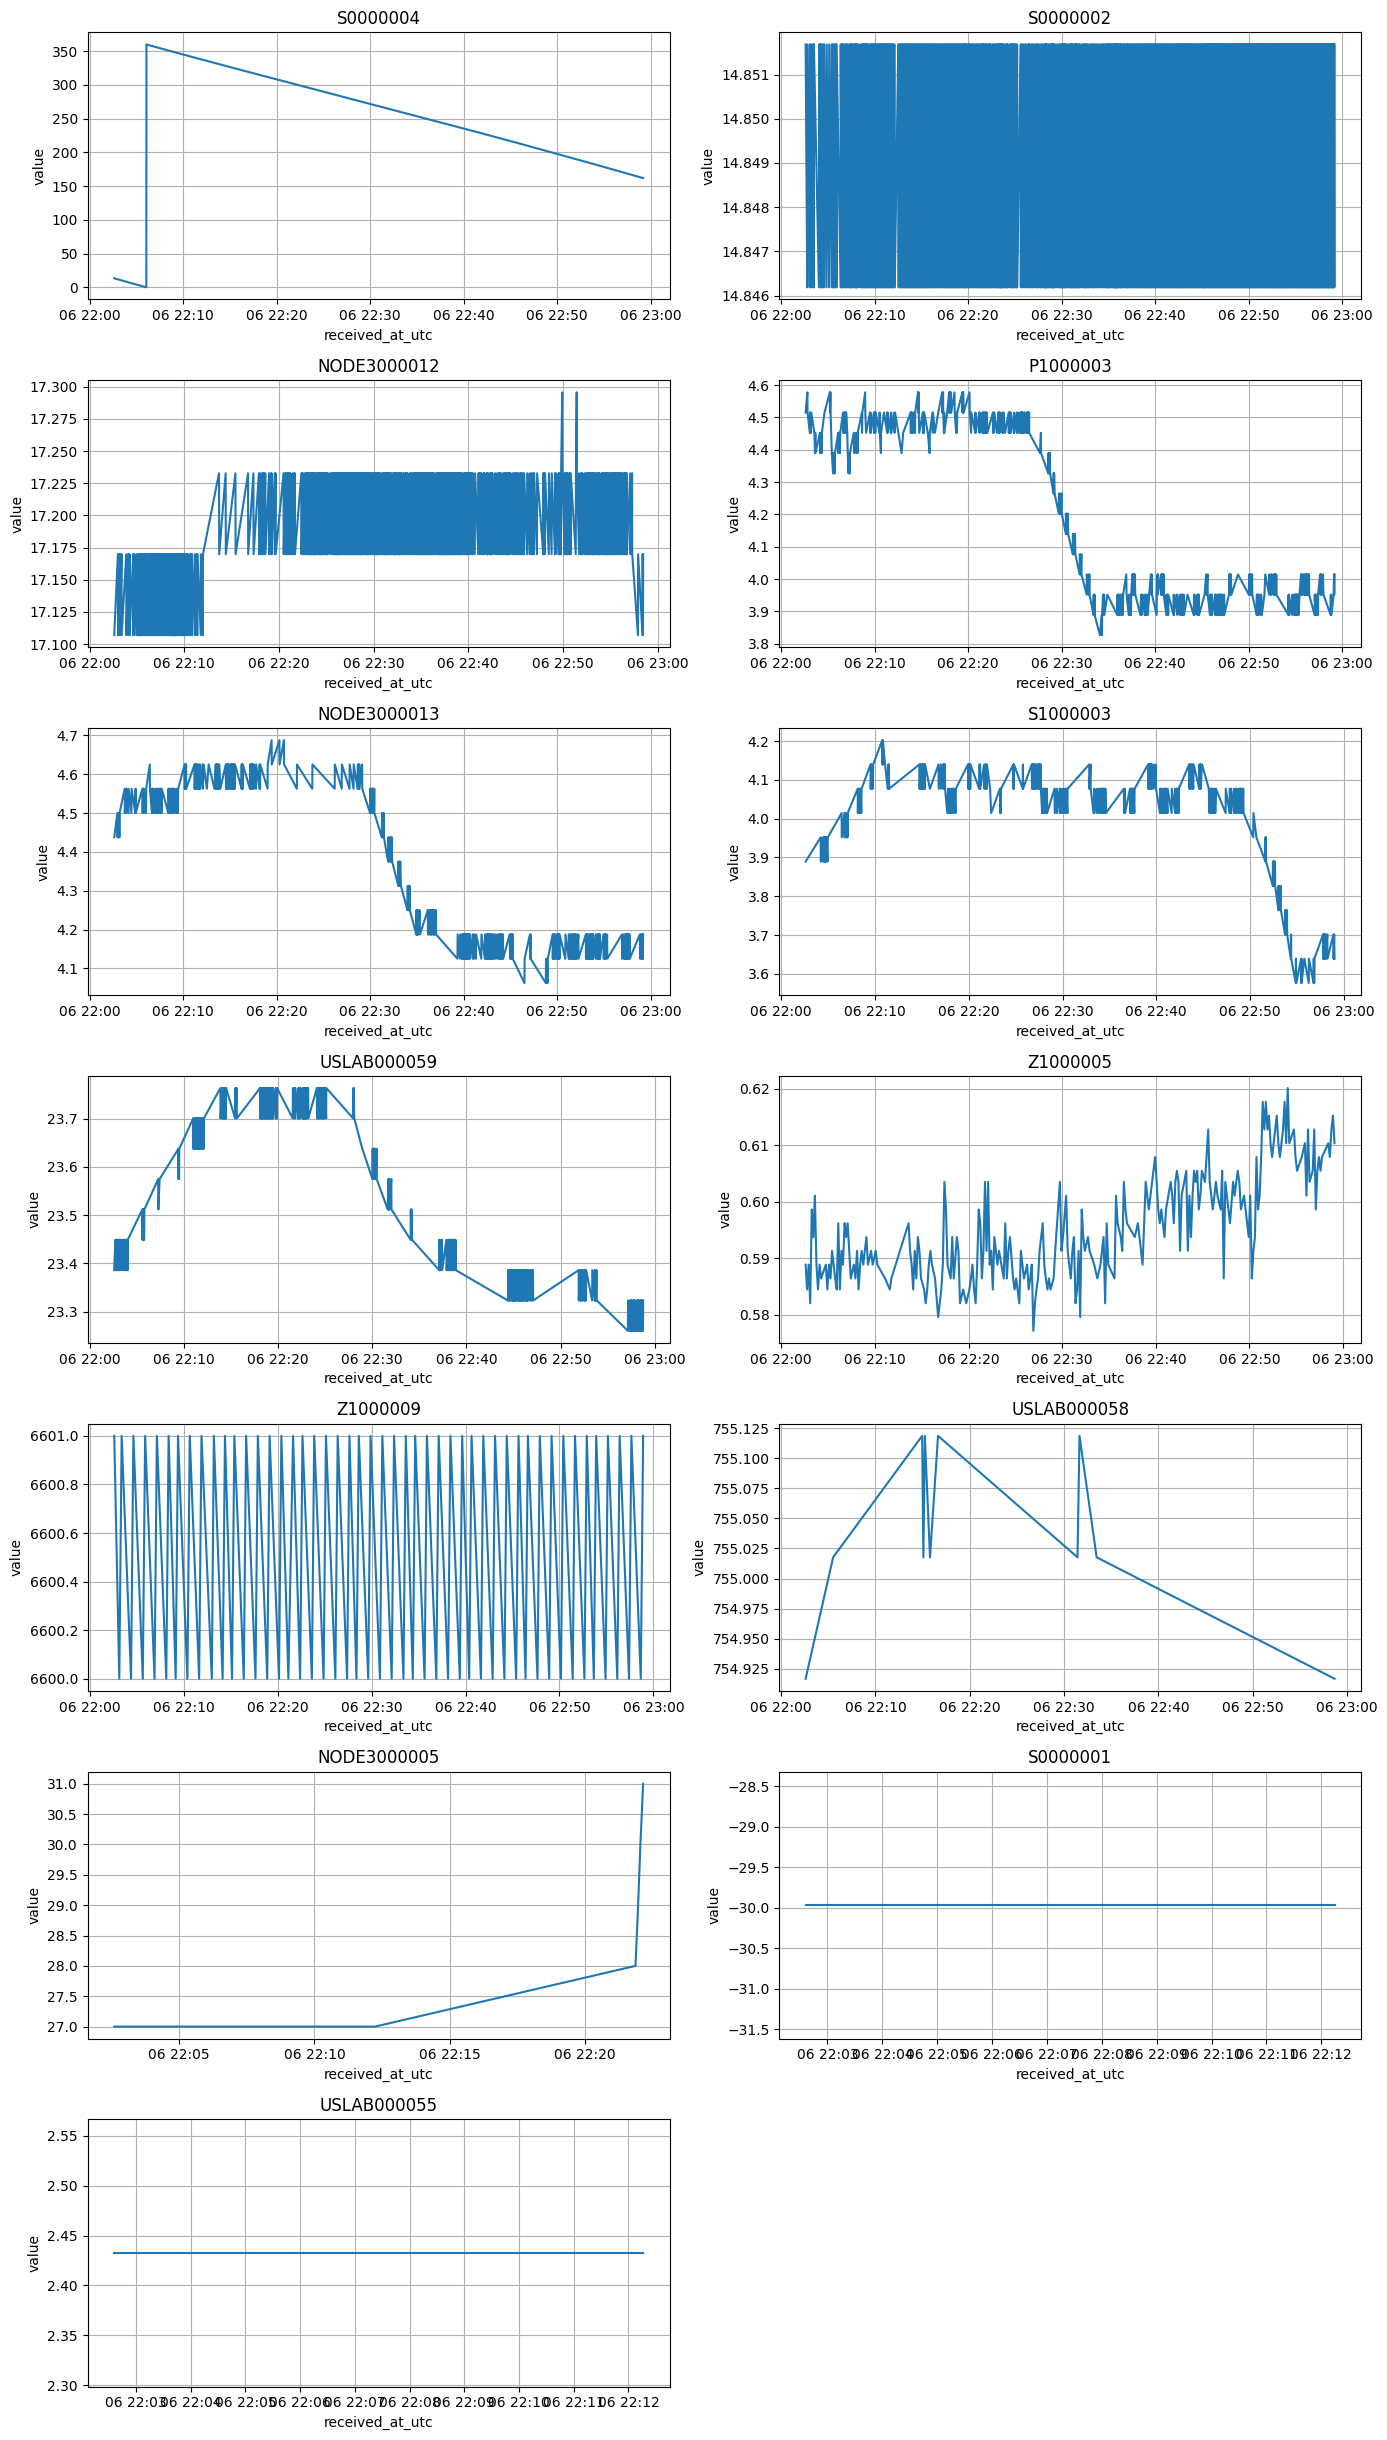

In [6]:
# Plot one time-series chart per item using numeric values only.
numeric_df = df.dropna(subset=['value_numeric']).copy()
items = list(summary_df['item'])

if numeric_df.empty:
    print('No numeric telemetry values available to plot.')
else:
    n_items = len(items)
    ncols = 2
    nrows = math.ceil(n_items / ncols)

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, 3.5 * nrows), squeeze=False)
    axes = axes.flatten()

    for index, item in enumerate(items):
        ax = axes[index]
        item_df = numeric_df[numeric_df['item'] == item]

        if item_df.empty:
            ax.set_title(f'{item} (no numeric data)')
            ax.axis('off')
            continue

        ax.plot(item_df['received_at_utc'], item_df['value_numeric'], linewidth=1.5)
        ax.set_title(item)
        ax.set_xlabel('received_at_utc')
        ax.set_ylabel('value')

    for index in range(len(items), len(axes)):
        axes[index].axis('off')

    fig.tight_layout()
    plt.show()

## 7. Plot One Histogram Per Item

Histograms help you see value spread, clustering, and whether a channel is mostly constant.

Again, only numeric values are plotted.

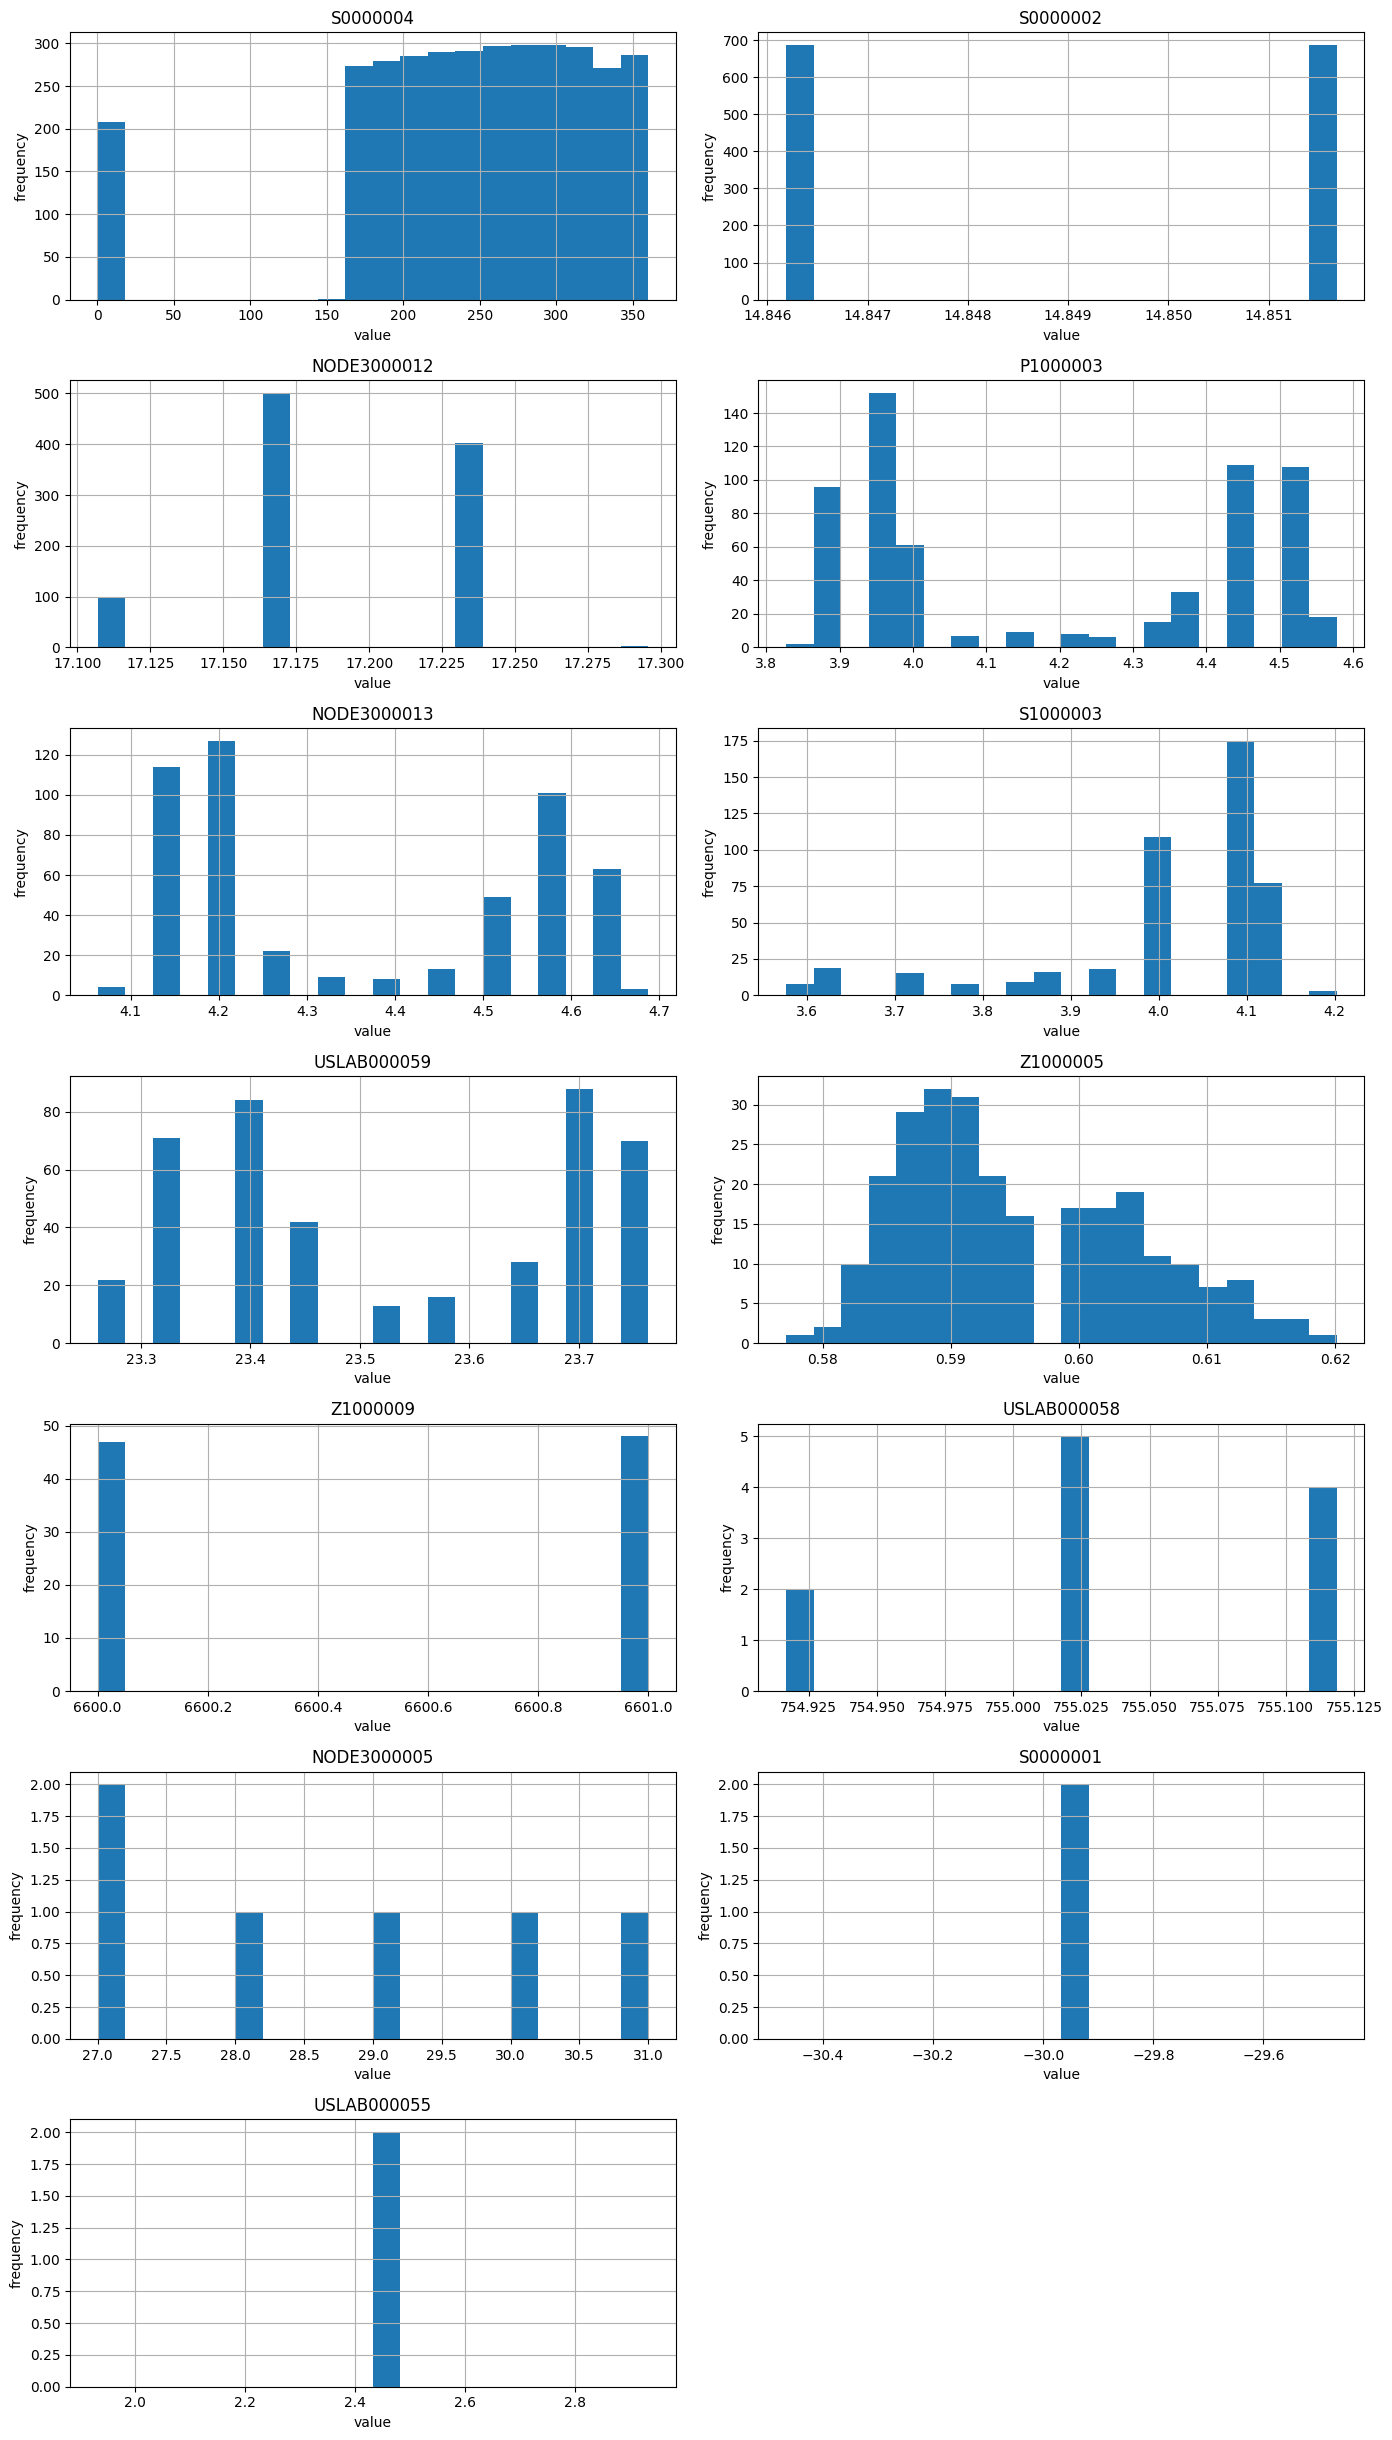

In [7]:
# Plot one histogram per item using numeric values only.
if numeric_df.empty:
    print('No numeric telemetry values available to plot.')
else:
    n_items = len(items)
    ncols = 2
    nrows = math.ceil(n_items / ncols)

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, 3.5 * nrows), squeeze=False)
    axes = axes.flatten()

    for index, item in enumerate(items):
        ax = axes[index]
        item_df = numeric_df[numeric_df['item'] == item]

        if item_df.empty:
            ax.set_title(f'{item} (no numeric data)')
            ax.axis('off')
            continue

        ax.hist(item_df['value_numeric'], bins=20)
        ax.set_title(item)
        ax.set_xlabel('value')
        ax.set_ylabel('frequency')

    for index in range(len(items), len(axes)):
        axes[index].axis('off')

    fig.tight_layout()
    plt.show()

## 8. What To Look For Next

After running this notebook, a few practical questions usually help:
- Which items update often enough to support live charts?
- Which items show enough movement to be interesting?
- Which items are mostly flat or repeated?
- Which items have outliers, jumps, or unusual distributions?

Those answers will help you choose a small set of channels for your next anomaly-detection or frontend step.